# Paper Figures — ICML Submission

**Regime-Aware Bayesian Deferral for Seismic Phase Picking Under Distribution Shift**

This notebook generates publication-ready figures from the same data as the main analysis notebook (`Notebook - 3 March.ipynb`). Each figure is formatted for ICML single-column width (3.25 inches) and saved as both PDF (for LaTeX) and PNG (for quick preview) in the `figures/` directory.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# Publication rcParams
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'figure.figsize': (3.25, 2.5),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,       # TrueType fonts in PDF (required by many venues)
    'ps.fonttype': 42,
})

# Create figures directory if needed
os.makedirs('figures', exist_ok=True)

print(f'matplotlib {matplotlib.__version__}')

matplotlib 3.10.0


In [2]:
# Data loading
# The main notebook (Notebook - 3 March.ipynb) produces results_df and kz_results_df
# but does not save them to disk. We need to either:
#   (a) Run the main notebook first and save the DataFrames, or
#   (b) Load them from the main notebook's namespace (if using %run or similar)
#
# Option 1: Load from CSV (preferred, if available)
# Option 2: Re-run the main notebook pipeline (slow, requires network access)

csv_dir = '.'  # Update if CSVs are saved elsewhere

try:
    results_df = pd.read_csv(os.path.join(csv_dir, 'results_df.csv'))
    kz_results_df = pd.read_csv(os.path.join(csv_dir, 'kz_results_df.csv'))
    print(f'Loaded from CSV: California {len(results_df)} picks, Kazakhstan {len(kz_results_df)} picks')
except FileNotFoundError:
    print('CSV files not found. Please run the main notebook and save the DataFrames:')
    print('  results_df.to_csv("results_df.csv", index=False)')
    print('  kz_results_df.to_csv("kz_results_df.csv", index=False)')
    print('Then re-run this cell.')
    raise

Loaded from CSV: California 563 picks, Kazakhstan 190 picks


## Figure 2: Confidence Distributions

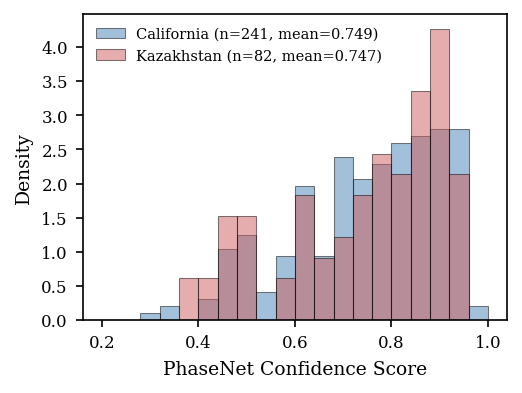

California matched: n=241, mean conf=0.749
Kazakhstan matched: n=82, mean conf=0.747


In [3]:
# Figure 2: Confidence distributions for matched picks
# Reproduces the bottom panel of Cell 76 (Figure 7b) from the main notebook

plt.rcParams['font.family'] = 'serif'

ca_matched = results_df[results_df['matched']]
kz_matched = kz_results_df[kz_results_df['matched']]

ca_conf = ca_matched['confidence'].values
kz_conf = kz_matched['confidence'].values

bins = np.linspace(0.2, 1.0, 21)

fig, ax = plt.subplots(figsize=(3.25, 2.5))

ax.hist(ca_conf, bins=bins, density=True, alpha=0.5,
        color='steelblue', edgecolor='black', linewidth=0.5,
        label=f'California (n={len(ca_conf)}, mean={ca_conf.mean():.3f})')

ax.hist(kz_conf, bins=bins, density=True, alpha=0.5,
        color='indianred', edgecolor='black', linewidth=0.5,
        label=f'Kazakhstan (n={len(kz_conf)}, mean={kz_conf.mean():.3f})')

ax.set_xlabel('PhaseNet Confidence Score')
ax.set_ylabel('Density')
ax.legend(frameon=False, fancybox=False, edgecolor='gray')
ax.tick_params(axis='both', labelsize=8)

plt.tight_layout(pad=0.3)
plt.savefig('figures/fig2_confidence.pdf', bbox_inches='tight')
plt.savefig('figures/fig2_confidence.png', bbox_inches='tight', dpi=300)
plt.show()

print(f'California matched: n={len(ca_conf)}, mean conf={ca_conf.mean():.3f}')
print(f'Kazakhstan matched: n={len(kz_conf)}, mean conf={kz_conf.mean():.3f}')

## Figure 3: Regime Posteriors

In [4]:
# Data loading for regime posteriors
# The main notebook (Step 5c) produces regime_posteriors, week_starts, and m45_trigger_df.
# These must be saved as files first. Add to the main notebook after Step 5c:
#
#   import pickle
#   with open('regime_posteriors.pkl', 'wb') as f:
#       pickle.dump({'regime_posteriors': regime_posteriors,
#                    'week_starts': week_starts}, f)
#   m45_trigger_df.to_csv('m45_trigger_df.csv', index=False)

import pickle

try:
    with open('regime_posteriors.pkl', 'rb') as f:
        regime_data = pickle.load(f)
    regime_posteriors = regime_data['regime_posteriors']
    week_starts = regime_data['week_starts']
    m45_trigger_df = pd.read_csv('m45_trigger_df.csv')
    print(f'Loaded regime data: {len(regime_posteriors)} stations, {len(week_starts)} weeks')
except FileNotFoundError:
    print('Regime data files not found. Please run the main notebook and save:')
    print('  import pickle')
    print('  with open("regime_posteriors.pkl", "wb") as f:')
    print('      pickle.dump({"regime_posteriors": regime_posteriors,')
    print('                   "week_starts": week_starts}, f)')
    print('  m45_trigger_df.to_csv("m45_trigger_df.csv", index=False)')
    raise

Loaded regime data: 11 stations, 209 weeks


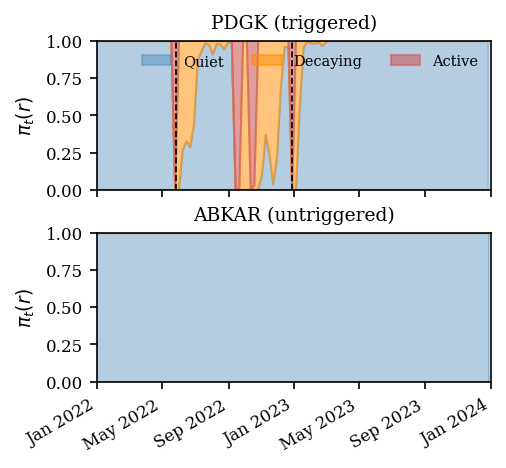

Figure 3 saved.


In [5]:
# Figure 3: Regime posterior stacked area chart
# Two panels: PDGK (triggered) and ABKAR (untriggered)
# Zoomed to 2022-2024 to show regime transitions clearly

import matplotlib.dates as mdates

stations_to_plot = ['PDGK', 'ABKAR']
titles = {'PDGK': 'PDGK (triggered)', 'ABKAR': 'ABKAR (untriggered)'}

# PDGK triggers: M5.1 on 2022-05-26, M5.0 on 2022-12-28
pdgk_triggers = [pd.Timestamp('2022-05-26'), pd.Timestamp('2022-12-28')]

dates = pd.to_datetime(week_starts)

fig, axes = plt.subplots(2, 1, figsize=(3.25, 3.0), sharex=True)

for i, station in enumerate(stations_to_plot):
    ax = axes[i]
    p = np.array(regime_posteriors[station])  # shape (n_weeks, 3): [Quiet, Active, Decaying]

    # Stacked areas: Quiet (bottom), then Decaying, then Active on top
    ax.fill_between(dates, 0, p[:, 0],
                    color='steelblue', alpha=0.4, label='Quiet')
    ax.fill_between(dates, p[:, 0], p[:, 0] + p[:, 2],
                    color='darkorange', alpha=0.5, label='Decaying')
    ax.fill_between(dates, p[:, 0] + p[:, 2], 1.0,
                    color='indianred', alpha=0.6, label='Active')

    # Trigger lines for PDGK
    if station == 'PDGK':
        for t in pdgk_triggers:
            ax.axvline(t, color='black', linestyle='--', linewidth=0.8)

    ax.set_ylabel(r'$\pi_t(r)$')
    ax.set_ylim(0, 1)
    ax.set_xlim(pd.Timestamp('2022-01-01'), pd.Timestamp('2024-01-01'))
    ax.set_title(titles[station], fontsize=9)
    ax.tick_params(axis='both', labelsize=8)

    if i == 0:
        ax.legend(fontsize=7, frameon=False, loc='upper right', ncol=3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=4))
axes[-1].set_xlabel('')
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout(pad=0.3)
plt.savefig('figures/fig3_regimes.pdf', bbox_inches='tight')
plt.savefig('figures/fig3_regimes.png', bbox_inches='tight', dpi=300)
plt.show()

print('Figure 3 saved.')